In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
Path to dataset files: /kaggle/input/140k-real-and-fake-faces


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
from torch.utils.data import Subset

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

path = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"

full_dataset = datasets.ImageFolder(path, transform=transform)

# sirf 5000 images use karo
small_dataset = Subset(full_dataset, range(5000))

loader = DataLoader(small_dataset, batch_size=64, shuffle=True)

print("Dataset Loaded:", len(small_dataset))

Dataset Loaded: 5000


In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 3*64*64),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.model(x)
        return x.view(-1,3,64,64)

G = Generator().to(device)

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(3*64*64, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

D = Discriminator().to(device)

In [7]:
loss_fn = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

In [8]:
epochs = 3

for epoch in range(epochs):

    for real,_ in loader:

        real = real.to(device)
        batch = real.size(0)

        # REAL LABEL = 1
        real_labels = torch.ones(batch,1).to(device)

        # FAKE LABEL = 0
        fake_labels = torch.zeros(batch,1).to(device)

        # ====================
        # Train Generator
        # ====================

        noise = torch.randn(batch,100).to(device)

        fake = G(noise)

        pred = D(fake)

        g_loss = loss_fn(pred, real_labels)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # ====================
        # Train Discriminator
        # ====================

        real_pred = D(real)
        fake_pred = D(fake.detach())

        real_loss = loss_fn(real_pred, real_labels)
        fake_loss = loss_fn(fake_pred, fake_labels)

        d_loss = real_loss + fake_loss

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch+1} | D Loss: {d_loss.item()} | G Loss: {g_loss.item()}")

Epoch 1 | D Loss: 0.005667258985340595 | G Loss: 5.653767108917236
Epoch 2 | D Loss: 0.0032302418258041143 | G Loss: 6.2213239669799805
Epoch 3 | D Loss: 0.022103622555732727 | G Loss: 3.882521629333496


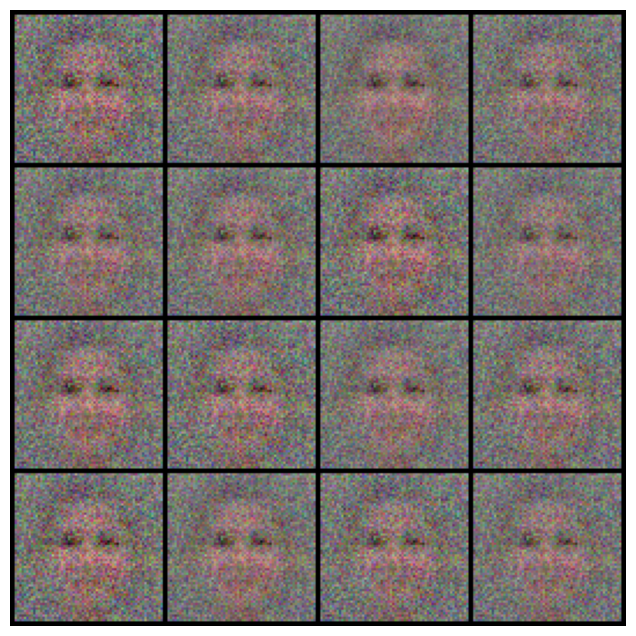

In [9]:
noise = torch.randn(16,100).to(device)

fake_images = G(noise).detach().cpu()

grid = vutils.make_grid(fake_images, normalize=True, nrow=4)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.show()